In [4]:
# 데이터 불러오기

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/wine.csv'
df = pd.read_csv(path)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 데이터 출력해서 확인
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
#label, feature 데이터 입력하

y=df['Alcohol']

X=df.drop('Alcohol',axis=1)

In [8]:
y.value_counts()
X.head()

,Wine,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [9]:
# numpy 변환
X = X.values # 엑셀 형태 → 숫자 배열로 변환하기 위해 사

# 정규화 (데이터를 비슷한 범위로 맞추는 작업)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [11]:
from tensorflow.keras import layers, models
# 층(layer)을 순서대로 쌓는 모델, 입력 → 은닉층 → 출력층으로 일직선 구조

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # 첫 번째 층 (입력층 + 은닉층),
    # 뉴런(노드) 64개, 입력 데이터의 컬럼 개수, activation="relu" <- 활성화 함수
    layers.Dropout(0.3), # 30% 뉴런을 랜덤으로 off > 과적합 방지
    layers.Dense(32, activation="relu"),# 두 번째 은닉층, 뉴런을 64 → 32로 줄이면서 중요한 정보만 남김
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 컴파일
model.compile(
    optimizer="adam", # 가중치 업데이트 방법, 자동으로 학습률 조정
    loss="mae",
    metrics=["mae"] # 평가 척
)

In [13]:
# 모델학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 학습 데이터 중 20%를 검증용으로 사용
    epochs=50, # 전체 데이터를 50번 반복 학습
    batch_size=16, # 한 번에 16개씩 학습
    verbose=1 # 학습 과정 출력
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 12.3534 - mae: 12.3534 - val_loss: 12.0970 - val_mae: 12.0970
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.8641 - mae: 11.8641 - val_loss: 11.6118 - val_mae: 11.6118
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.2282 - mae: 11.2282 - val_loss: 11.0566 - val_mae: 11.0566
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 10.5352 - mae: 10.5352 - val_loss: 10.3882 - val_mae: 10.3882
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.6424 - mae: 9.6424 - val_loss: 9.5870 - val_mae: 9.5870
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.7794 - mae: 8.7794 - val_loss: 8.6236 - val_mae: 8.6236
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.6118 - mae: 7.6118 - val_loss: 7.4537 - val_mae: 7.4537
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.2716 - mae: 6.2716 - val_loss: 6.0718 - val_mae: 6.0718
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.5951 - mae

In [14]:

y_pred = model.predict(X_test) # 결과 = 확률


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [15]:
# 그래프 그리기용 데이터 저장
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']


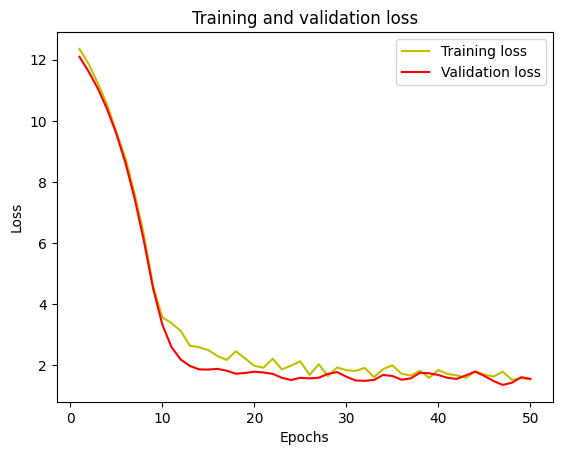

In [16]:
# 학습 과정에서 손실(loss)이 어떻게 변하는지 시각화

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


loss = history.history['loss'] # loss = 훈련 데이터 오차 /
val_loss = history.history['val_loss'] # val_loss = 검증 데이터 오차
# history는 model.fit() 결과

mae = history.history['mae']
val_mae = history.history['val_mae'] # 결과 척

epochs = range(1, len(loss) + 1) # x축 만들기

plt.plot(epochs, loss, 'y', label='Training loss') # 훈련 데이터 손실
# x축: epoch y축: loss 'y': 노란색
plt.plot(epochs, val_loss, 'r', label='Validation loss') # 검증 데이터 손실
# 'r': 빨간색
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


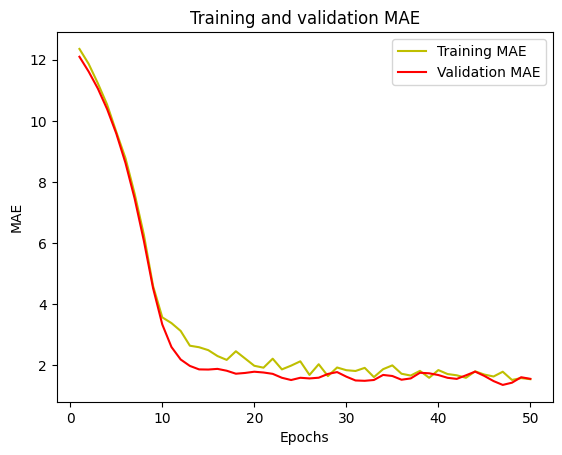

In [17]:
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [18]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

MAE : 1.4130805774264863
MSE : 3.349368643483274
RMSE: 1.830128040188247
